### Import Packages

In [ ]:
import random

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score, accuracy_score

In [ ]:
SEED = 10

In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

### Load Dataset

In [ ]:
df = pd.read_csv('pew_data.csv', encoding="unicode-escape")

In [ ]:
df.head()

,qkey,intervie,interv_1,device_t,lang_w90,pers1_w9,pers11_w,selfmoni,talkpol_,civeng_g,...,f_partyl,f_partys,f_part_1,f_inc_sd,f_reg,f_ideo,f_intfre,f_volsum,f_inc_ti,weight_w
0,100588,5/24/2021 11:20:46,5/24/2021 11:30:08,Smartphone,English,2,4,Rarely,Less often,"No, I have not done this in the past year",...,,Dem/Lean Dem,Moderate/Conservative Dem/Lean,"$50,000 to less than $60,000",You are ABSOLUTELY CERTAIN that you are regist...,Moderate,Almost constantly,No,Middle income,0.449626
1,101400,5/26/2021 23:34:08,5/27/2021 0:04:35,Smartphone,English,4,4,Sometimes,Nearly every day,"No, I have not done this in the past year",...,,Dem/Lean Dem,Liberal Dem/Lean,"$50,000 to less than $60,000",You are ABSOLUTELY CERTAIN that you are regist...,Liberal,Several times a day,No,Middle income,0.222799
2,101437,5/18/2021 16:17:42,5/18/2021 16:35:24,Laptop/PC,English,4,3,Often,Nearly every day,Refused,...,The Republican Party,Rep/Lean Rep,Conservative Rep/Lean,"Less than $30,000",You are ABSOLUTELY CERTAIN that you are regist...,Conservative,Several times a day,No,Lower income,0.486452
3,101472,5/25/2021 16:23:40,5/25/2021 16:32:03,Laptop/PC,English,2,4,Rarely,A few times a week,"No, I have not done this in the past year",...,The Democratic Party,Dem/Lean Dem,Moderate/Conservative Dem/Lean,"$100,000 or more",You are ABSOLUTELY CERTAIN that you are regist...,Moderate,Almost constantly,No,Upper income,0.407040
4,101485,5/18/2021 20:37:54,5/18/2021 20:47:56,Smartphone,English,3,3,Sometimes,A few times a month,"No, I have not done this in the past year",...,The Republican Party,Rep/Lean Rep,Conservative Rep/Lean,"$100,000 or more",You are ABSOLUTELY CERTAIN that you are regist...,Conservative,Almost constantly,Yes,Upper income,0.529000


In [ ]:
len(list(df.columns))

126

In [ ]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

### Features Dictionary

In [ ]:
vars = {
    "Civic Engagement": {
        "HOBBYISM": "Captures the respondent's primary motivation for participating in politics.",
        "TALKPOL_": "Measures how often the respondent discusses government and politics in person.",
        "TWDEMOCR": "Measures whether the respondent believes Twitter is good or bad for democracy.",
        "CIVEN_10": "Indicates whether the respondent tweeted or retweeted about a political or social issue in the past year.",
        "CIVEN_11": "Indicates whether the respondent tweeted or retweeted about a protest, boycott, or similar call to action in the past year.",
        "CIVEN_12": "Indicates whether the respondent tweeted or retweeted memes or humorous content related to political or social issues in the past year.",
        "CIVENG_1": "Indicates whether the respondent contributed money to a candidate running for public office or to a political or social cause in the past year.",
        "CIVENG_2": "Indicates whether the respondent displayed a poster, sign, bumper sticker, or wore clothing in support of a political campaign in the past year.",
        "CIVENG_3": "Indicates whether the respondent worked or volunteered for a political party, candidate, or campaign in the past year.",
        "CIVENG_4": "Indicates whether the respondent signed a petition in the past year.",
        "CIVENG_5": "Indicates whether the respondent attended a protest or demonstration in the past year.",
        "CIVENG_6": "Indicates whether the respondent voted in an election in the past year.",
        "CIVENG_7": "Indicates whether the respondent replied to a tweet from a politician, political campaign, or candidate in the past year.",
        "CIVENG_8": "Indicates whether the respondent posted a picture or changed their profile picture to show support for a cause in the past year.",
        "CIVENG_9": "Indicates whether the respondent used a hashtag related to political or social issues in the past year.",
        "CIVENG_G": "Indicates whether the respondent attended a political rally or campaign event in the past year.",
        "CIVENG_T": "Indicates whether the respondent expressed support for a political campaign or candidate on Twitter in the past year."
    },
    "Privacy Concerns": {
        "ENCTRDIS": "Measures how often the respondent sees political views or opinions they disagree with on Twitter.",
        "CONCER_1": "Measures the respondent's concern about how much information about them is available online for others to see.",
        "CONCERNT": "Measures the respondent's concern about how much social media sites know about their online activities."
    },
    "Social Media Considerations": {
        "TWPROB_1": "Measures the respondent's opinion on whether Twitter banning users is a problem.",
        "TWPROB_2": "Measures the respondent's opinion on whether Twitter limiting the visibility of certain posts is a problem.",
        "TWPROB_3": "Measures the respondent's opinion on whether harassment and abuse from other users is a problem on Twitter.",
        "TWPROB_4": "Measures the respondent's opinion on whether inaccurate or misleading information is a problem on Twitter.",
        "TWPROBLE": "Measures the respondent's opinion on whether the tone or civility of discussions on Twitter is a problem.",
        "TWHARASS": "Captures whether the respondent has personally experienced harassment or abusive behavior on Twitter.",
        "TWREGRET": "Indicates whether the respondent has ever posted something on Twitter that they later regretted.",
        "CONSID_1": "Measures how much the respondent considers whether something they do on Twitter could be used against them in the future.",
        "CONSID_2": "Measures how much the respondent considers the potential for others to attack or harass them on Twitter.",
        "CONSID_3": "Measures how much the respondent considers who can see their activity on Twitter.",
        "CONSID_4": "Measures how much the respondent considers whether their activity on Twitter portrays them in a positive light.",
        "CONSIDER": "Measures how much the respondent considers whether their Twitter activity will offend people who follow them."
    },
    "Demographics": {
        "F_INC_SD": "Represents a recoded version of the respondent's household income category.",
        "F_INC_TI": "Represents another recoded version of household income into tiers.",
        "F_INTFRE": "Measures how often the respondent accesses the internet.",
        "F_MARITA": "Captures the respondent's marital status.",
        "F_PART_1": "Represents a summary of the respondent's party identification and ideological leanings.",
        "F_RELIGC": "Categorizes the respondent's religious affiliation.",
        "F_AGECAT": "Categorizes the respondent's age into broad groups (e.g., 18-29, 30-49, 50-64, 65+).",
        "F_ATTEND": "Measures how frequently the respondent attends religious services, excluding weddings and funerals.",
        "F_BIRTHP": "Captures the respondent's place of birth.",
        "F_BORN": "Captures whether the respondent identifies as a born-again or evangelical Christian.",
        "F_CDIVIS": "Indicates the Census division where the respondent resides.",
        "F_CITIZE": "Indicates whether the respondent is a U.S. citizen.",
        "F_CREGIO": "Indicates the Census region where the respondent resides.",
        "F_EDUC_1": "Categorizes the respondent's highest level of education into six levels.",
        "F_EDUCCA": "Categorizes the respondent's highest level of education into three broad categories.",
        "F_GENDER": "Records the respondent's self-reported gender as male or female.",
        "F_HISP": "Indicates whether the respondent identifies as Hispanic, Latino, or of Spanish origin.",
        "F_HISP_O": "Captures whether the respondent identifies as Hispanic or Latino.",
        "F_IDEO": "Measures the respondent's self-reported political ideology on a scale from very conservative to very liberal.",
        "F_METRO": "Indicates whether the respondent resides in a metropolitan or non-metropolitan area.",
        "F_PARTY_": "Captures the respondent's self-reported political party affiliation.",
        "F_PARTYL": "Indicates the respondent's political party leanings if they are independent or belong to another party.",
        "F_PARTYS": "Represents a recoded summary of the respondent's party identification.",
        "F_RACECM": "Represents the respondent's racial identity.",
        "F_RACETH": "Combines race and ethnicity to classify the respondent.",
        "F_REG": "Captures the respondent's voter registration status, indicating whether they are registered to vote at their current address.",
        "F_RELIG": "Categorizes the respondent's religious affiliation, including Protestant, Catholic, Jewish, Muslim, atheist, and others.",
        "F_VOLSUM": "Summarizes the respondent's engagement in volunteering or civic activities.",
        "F_YEARSI": "Indicates the number of years the respondent has lived in the U.S."
    },
    "Personality and Political Leanings": {
        "PERS1_W9": "Measures the respondent's placement on personality traits such as introversion/extroversion and critical/accepting.",
        "PERS11_W": "Another personality trait placement question.",
        "QBELIEFG": "Measures whether the respondent perceives that most accounts they follow share their political beliefs.",
        "QBELIEFP": "Measures whether the politicians or government figures the respondent follows share their political beliefs.",
        "SELFMONI": "Measures how often the respondent is the center of attention in a group setting."
    },
    "Twitter Influence and Political Content": {
        "SOCEFF_1": "Assesses Twitter's effectiveness in changing people's opinions on political or social issues.",
        "SOCEFF_2": "Assesses Twitter's effectiveness in raising public awareness about political or social issues.",
        "SOCEFF1_": "Assesses Twitter's effectiveness in getting elected officials to pay attention to issues.",
        "SOURCESK": "Measures the respondent's trust in news from Twitter.",
        "TWLIKERT": "Measures how much of what the respondent likes or retweets on Twitter is related to political or social issues.",
        "TWNEWSNE": "Measures how often the respondent sees news on Twitter that they have already seen elsewhere.",
        "TWPOST2M": "Measures how much of what the respondent tweets is related to political or social issues.",
        "TWSEE1_W": "Measures how much of what the respondent sees on Twitter is related to political or social issues.",
        "TWSEE2_A": "Measures how often the respondent sees news articles about political or social issues on Twitter.",
        "TWSEE2_B": "Measures how often the respondent sees funny or parody videos referencing political or social issues on Twitter.",
        "TWSEE2_C": "Measures how often the respondent sees petitions related to political or social change on Twitter.",
        "TWSEE2_D": "Measures how often the respondent sees political memes on Twitter.",
        "TWSEE2_E": "Measures how often the respondent sees campaign advertisements on Twitter.",
        "TWTRAMOU": "Measures whether the respondent feels overwhelmed by the amount of news on Twitter or enjoys the amount of news available.",
        "TWTRLIVE": "Indicates whether the respondent has used Twitter to follow a news event as it is happening.",
        "TWTRNEWS": "Measures how important Twitter is to the respondent as a way of keeping up with the news."
    },
    "Twitter Content and Activity": {
        "TWEETA_1": "Indicates whether the respondent has tweeted or retweeted about movies, music, or pop culture.",
        "TWEETA_2": "Indicates whether the respondent has tweeted or retweeted about their hobbies.",
        "TWEETA_3": "Indicates whether the respondent has tweeted or retweeted about sports.",
        "TWEETABO": "Indicates whether the respondent has tweeted or retweeted about political or social issues.",
        "TWIDENTI": "Measures how easy it would be for someone visiting the respondent's Twitter profile to determine their hobbies and interests.",
        "TWIDEN_1": "Measures how easy it would be for someone visiting the respondent's Twitter profile to determine their views on political or social issues.",
        "TWIDEN_2": "Measures how easy it would be for someone visiting the respondent's Twitter profile to determine their race or ethnicity.",
        "TWITTER_": "Captures whether the respondent gets news or news headlines from Twitter."
    },
    "Twitter Follow Behavior": {
        "WHOFOL_1": "Indicates whether the respondent follows actors, musicians, sports personalities, or other celebrities on Twitter.",
        "WHOFOL_2": "Indicates whether the respondent follows news sites or reporters on Twitter.",
        "WHOFOL_3": "Indicates whether the respondent follows politicians or government figures on Twitter.",
        "WHOFOL_4": "Indicates whether the respondent follows accounts that primarily post humor or memes on Twitter.",
        "WHOFOLLO": "Indicates whether the respondent follows friends, family, or coworkers on Twitter.",
        "YOUFOLLO": "Estimates how many Twitter accounts the respondent follows."
    },
    "Reasons for Using Twitter": {
        "WHYUSE1_": "Indicates whether entertainment is a reason the respondent uses Twitter.",
        "WHYUSE_1": "Indicates whether staying informed is a reason the respondent uses Twitter.",
        "WHYUSE_2": "Indicates whether expressing opinions is a reason the respondent uses Twitter.",
        "WHYUSE_3": "Indicates whether staying connected with other people is a reason the respondent uses Twitter.",
        "WHYUSE_4": "Indicates whether seeing different points of view is a reason the respondent uses Twitter.",
        "WHYUSE_5": "Indicates whether using Twitter for work or school is a reason the respondent uses the platform.",
        "WHYUSE1C": "Captures the respondent's primary reason for using Twitter when multiple reasons apply.",
        "WHYUSE2_": "Captures the most important reason why the respondent uses Twitter when they selected multiple reasons."
    },
    "COVID-19": {
        "COVID_SC": "Captures the respondent's likelihood of getting a COVID-19 vaccine if they have not yet received one.",
        "COVID_VA": "Indicates whether the respondent has received at least one dose of a COVID-19 vaccine.",
        "VACCNFDT": "Measures the respondent's confidence in the safety and effectiveness of COVID-19 vaccines."
    },
    "Device and Survey Metadata": {
        "DEVICE_T": "Records the type of device used by the respondent to take the survey.",
        "INTERV_1": "Records the time when the respondent completed the survey.",
        "INTERVIE": "Records the time when the respondent started the survey.",
        "LANG_W90": "Indicates the language in which the respondent completed the survey.",
        "QKEY": "Serves as a unique identifier assigned to each respondent to link multiple survey waves together."
    },
    "Twitter Usage and Behavior": {
        "FREQUSE_": "Measures how often the respondent visits Twitter.",
        "FREQUSED": "Measures how frequently the respondent visits Twitter on a typical day.",
        "LIKETWEE": "Measures how often the respondent likes tweets on Twitter.",
        "MISYOU_W": "Captures how much inaccurate or misleading information the respondent encounters on Twitter.",
        "POSTLURK": "Measures whether the respondent primarily uses Twitter to read others' posts, express their opinions, or a mix of both.",
        "PUBPRIV_": "Indicates whether the respondent's Twitter account is public or private.",
        "WHOSEE_W": "Measures how many people the respondent believes see the content they share on Twitter.",
        "WHYLIKE_": "Measures the respondent's main reason for liking tweets on Twitter.",
        "FOLLOWYO": "Estimates the number of Twitter accounts that follow the respondent."
    },
    "Impact of Twitter Usage": {
        "USEIMP_1": "Measures how the respondent's use of Twitter has affected how politically engaged they feel.",
        "USEIMP_2": "Measures how the respondent's use of Twitter has affected their stress levels.",
        "USEIMP_3": "Measures how the respondent's use of Twitter has affected how much they know about the lives of celebrities and public figures.",
        "USEIMPAC": "Measures how the respondent's use of Twitter has affected their understanding of current events.",
        "WEIGHT_W": "Represents the weight assigned to the respondent's survey responses for statistical analysis."
    }
}

In [ ]:
var_names = []
for k, v in vars.items():
    var_names += [k.lower() for k in v.keys()]

In [ ]:
set(df.columns) == set(var_names)

True

In [ ]:
var_table = []
for k, v in vars.items():
    for k2, v2 in v.items():
        var_table.append([k, k2, v2])

var_table = pd.DataFrame(var_table, columns=['Category', 'Variable', 'Description'])
var_table.to_csv('var_table.csv', index=False)

### Data Cleaning & Preprocessing

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing

,0
whyuse2_,435
freqused,1552
twpost2m,1240
twsee1_w,128
twlikert,746
whylike_,312
qbeliefp,714
sourcesk,765
twtrnews,765
twnewsne,765


In [ ]:
missing.index.values

array(['whyuse2_', 'freqused', 'twpost2m', 'twsee1_w', 'twlikert',
       'whylike_', 'qbeliefp', 'sourcesk', 'twtrnews', 'twnewsne',
       'twtrlive', 'twtramou', 'misyou_w', 'covid_sc', 'f_hisp_o',
       'f_born', 'f_partyl', 'f_reg'], dtype=object)

In [ ]:
cols_to_drop = ['qkey', 'intervie', 'interv_1', 'weight_w']
cols_to_drop += ["f_part_1", "f_partys", 'f_partyl']
cols_to_drop += ['whyuse2_', 'freqused', 'twpost2m', 'twsee1_w', 'twlikert',
                'whylike_', 'qbeliefp', 'sourcesk', 'twtrnews', 'twnewsne',
                'twtrlive', 'twtramou', 'misyou_w', 'covid_sc', 'f_hisp_o',
                'f_born', 'f_reg']
df_cleaned = df.drop(cols_to_drop, axis=1)

In [ ]:
df_cleaned = df_cleaned[df_cleaned['f_ideo'] != "Refused"].copy()

In [ ]:
df_cleaned.head()

,device_t,lang_w90,pers1_w9,pers11_w,selfmoni,talkpol_,civeng_g,civeng_1,civeng_2,civeng_3,...,f_marita,f_relig,f_religc,f_attend,f_party_,f_inc_sd,f_ideo,f_intfre,f_volsum,f_inc_ti
0,Smartphone,English,2,4,Rarely,Less often,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Married,Roman Catholic,Catholic,A few times a year,Democrat,"$50,000 to less than $60,000",Moderate,Almost constantly,No,Middle income
1,Smartphone,English,4,4,Sometimes,Nearly every day,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Never been married,Atheist,Unaffiliated,Never,Democrat,"$50,000 to less than $60,000",Liberal,Several times a day,No,Middle income
2,Laptop/PC,English,4,3,Often,Nearly every day,Refused,"Yes, I have done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Divorced,Protestant,Protestant,Once a week,Independent,"Less than $30,000",Conservative,Several times a day,No,Lower income
3,Laptop/PC,English,2,4,Rarely,A few times a week,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Married,Roman Catholic,Catholic,A few times a year,Independent,"$100,000 or more",Moderate,Almost constantly,No,Upper income
4,Smartphone,English,3,3,Sometimes,A few times a month,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Widowed,Protestant,Protestant,Once a week,Independent,"$100,000 or more",Conservative,Almost constantly,Yes,Upper income


In [ ]:
df_cleaned.columns.values

array(['device_t', 'lang_w90', 'pers1_w9', 'pers11_w', 'selfmoni',
       'talkpol_', 'civeng_g', 'civeng_1', 'civeng_2', 'civeng_3',
       'civeng_4', 'civeng_5', 'civeng_6', 'hobbyism', 'concernt',
       'concer_1', 'soceff1_', 'soceff_1', 'soceff_2', 'twdemocr',
       'whyuse1_', 'whyuse_1', 'whyuse_2', 'whyuse_3', 'whyuse_4',
       'whyuse_5', 'whyuse1c', 'pubpriv_', 'frequse_', 'consider',
       'consid_1', 'consid_2', 'consid_3', 'consid_4', 'tweetabo',
       'tweeta_1', 'tweeta_2', 'tweeta_3', 'postlurk', 'liketwee',
       'youfollo', 'followyo', 'whofollo', 'whofol_1', 'whofol_2',
       'whofol_3', 'whofol_4', 'qbeliefg', 'enctrdis', 'twsee2_a',
       'twsee2_b', 'twsee2_c', 'twsee2_d', 'twsee2_e', 'twitter_',
       'useimpac', 'useimp_1', 'useimp_2', 'useimp_3', 'twproble',
       'twprob_1', 'twprob_2', 'twprob_3', 'twprob_4', 'whosee_w',
       'twharass', 'twregret', 'twidenti', 'twiden_1', 'twiden_2',
       'civeng_t', 'civeng_7', 'civeng_8', 'civeng_9', 'civen_

In [ ]:
categorical = [
    "device_t", "lang_w90", "f_party_", "f_partyl", "f_partys",
    "f_racecm", "f_raceth", "f_hisp", "f_relig", "f_religc",
    "f_citize", "f_birthp", "f_yearsi", "qbeliefg", "qbeliefp",
    "f_metro", "f_cregio", "f_cdivis", "f_gender", "f_marita",
    "f_reg", "twitter_", "whyuse1_", "whyuse_1", "whyuse_2",
    "whyuse_3", "whyuse_4", "whyuse_5", "civeng_g", "civeng_1",
    "civeng_2", "civeng_3", "civeng_4", "civeng_5", "civeng_6",
    "civeng_t", "civeng_7", "civeng_8", "civeng_9", "civen_10",
    "civen_11", "civen_12", "covid_va", "twharass",
    "twregret", "hobbyism", "whyuse2_", "pubpriv_", "whylike_",
    "f_hisp_o", "f_born", "f_volsum", "twtramou", "twtrlive"
]
len(categorical)

54

In [ ]:
ordinal = {
    "pers1_w9": {"Introverted": 1, "2": 2, "3": 3, "4": 4, "Extroverted": 5, "Refused": -1},
    "pers11_w": {"Critical of others": 1, "2": 2, "3": 3, "4": 4, "Accepting of others": 5, "Refused": -1},
    "selfmoni": {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Refused": -1},
    "talkpol_": {"Less often": 1, "A few times a month": 2, "A few times a week": 3, "Nearly every day": 4, "Refused": -1},
    "concernt": {"Not at all concerned": 1, "Not very concerned": 2, "Somewhat concerned": 3, "Very concerned": 4, "Refused": -1},
    "concer_1": {"Not at all concerned": 1, "Not very concerned": 2, "Somewhat concerned": 3, "Very concerned": 4, "Refused": -1},
    "soceff1_": {"Very ineffective": 1, "Somewhat ineffective": 2, "Somewhat effective": 3, "Very effective": 4, "Refused": -1},
    "soceff_1": {"Very ineffective": 1, "Somewhat ineffective": 2, "Somewhat effective": 3, "Very effective": 4, "Refused": -1},
    "soceff_2": {"Very ineffective": 1, "Somewhat ineffective": 2, "Somewhat effective": 3, "Very effective": 4, "Refused": -1},
    "twdemocr": {"Mostly BAD for American democracy": 1, "Has no impact on American democracy": 2, "Mostly GOOD for American democracy": 3, "Refused": -1},
    "whyuse1c": {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6},
    "frequse_": {"Less often": 1, "A few times a month": 2, "At least once a week but not every day": 3, "Every day": 4, "Refused": -1},
    "freqused": {"Once or twice": 1, "Occasionally throughout the day": 2, "Too many times to count": 3, "Refused": -1},
    "consider": {"Not at all": 1, "Not too much": 2, "Some": 3, "A great deal": 4, "Refused": -1},
    "consid_1": {"Not at all": 1, "Not too much": 2, "Some": 3, "A great deal": 4, "Refused": -1},
    "consid_2": {"Not at all": 1, "Not too much": 2, "Some": 3, "A great deal": 4, "Refused": -1},
    "consid_3": {"Not at all": 1, "Not too much": 2, "Some": 3, "A great deal": 4, "Refused": -1},
    "consid_4": {"Not at all": 1, "Not too much": 2, "Some": 3, "A great deal": 4, "Refused": -1},
    "tweetabo": {"No, I have not": 1, "Yes, but not in the last 30 days": 2, "Yes, in the last 30 days": 3, "Refused": -1},
    "tweeta_1": {"No, I have not": 1, "Yes, but not in the last 30 days": 2, "Yes, in the last 30 days": 3, "Refused": -1},
    "tweeta_2": {"No, I have not": 1, "Yes, but not in the last 30 days": 2, "Yes, in the last 30 days": 3, "Refused": -1},
    "tweeta_3": {"No, I have not": 1, "Yes, but not in the last 30 days": 2, "Yes, in the last 30 days": 3, "Refused": -1},
    "postlurk": {"Express your own opinions": 1, "An equal mix of both": 2, "See what others are saying": 3, "Refused": -1},
    "liketwee": {"Never": 1, "Rarely": 2, "Occasionally": 3, "Almost always": 4, "Refused": -1},
    "youfollo": {"Less than 20": 1, "20-99": 2, "100-499": 3, "500-999": 4, "1,000-4,999": 5, "More than 5,000": 6, "Refused": -1},
    "followyo": {"Less than 20": 1, "20-99": 2, "100-499": 3, "500-999": 4, "1,000-4,999": 5, "More than 5,000": 6, "Refused": -1},
    "enctrdis": {"None of them": 1, "Very few of them": 2, "Some of them": 3, "Most of them": 4, "Almost all of them": 5, "Refused": -1},
    "twsee2_a": {"Never": 1, "Rarely": 2, "Sometimes": 3, "Almost every time": 4, "Refused": -1},
    "twsee2_b": {"Never": 1, "Rarely": 2, "Sometimes": 3, "Almost every time": 4, "Refused": -1},
    "twsee2_c": {"Never": 1, "Rarely": 2, "Sometimes": 3, "Almost every time": 4, "Refused": -1},
    "twsee2_d": {"Never": 1, "Rarely": 2, "Sometimes": 3, "Almost every time": 4, "Refused": -1},
    "twsee2_e": {"Never": 1, "Rarely": 2, "Sometimes": 3, "Almost every time": 4, "Refused": -1},
    "useimpac": {"Decreased": 1, "Had no impact": 2, "Increased": 3, "Refused": -1},
    "twproble": {"Not a problem": 1, "A minor problem": 2, "A major problem": 3, "Refused": -1},
    "twidenti": {"Very difficult": 1, "Somewhat difficult": 2, "Somewhat easy": 3, "Very easy": 4, "Refused": -1},
    "vaccnfdt": {"No confidence at all": 1, "Not too much confidence": 2, "A fair amount of confidence": 3, "A great deal of confidence": 4, "Refused": -1},
    "f_intfre": {"Less often": 1, "Several times a week": 2, "About once a day": 3, "Several times a day": 4, "Almost constantly": 5, "Refused": -1},
    "f_inc_ti": {"Lower income": 1, "Middle income": 2, "Upper income": 3, "Refused": -1},
    "covid_sc": {"Definitely NOT get a vaccine": 1, "Probably NOT get a vaccine": 2, "Probably get a vaccine": 3, "Definitely get a vaccine": 4, "Refused": -1},
    "f_agecat": {"18-29": 1, "30-49": 2, "50-64": 3, "65+": 4, "Refused": -1},
    "f_attend": {"Never": 1, "Seldom": 2, "A few times a year": 3, "Once or twice a month": 4, "Once a week": 5, "More than once a week": 6, "Refused": -1},
    "f_educ_1": {"Less than high school": 1, "High school graduate": 2, "Some college, no degree": 3, "Associate's degree": 4, "College graduate/some post grad": 5, "Postgraduate": 6, "Refused": -1},
    "f_educca": {"H.S. graduate or less": 1, "Some College": 2, "College graduate+": 3, "Refused": -1},
    "f_inc_sd": {"Less than $30,000": 1, "$30,000 to less than $40,000": 2, "$40,000 to less than $50,000": 3, "$50,000 to less than $60,000": 4, "$60,000 to less than $70,000": 5, "$70,000 to less than $80,000": 6, "$80,000 to less than $90,000": 7, "$90,000 to less than $100,000": 8, "$100,000 or more": 9, "Refused": -1},
    "sourcesk": {"Not at all": 1, "Not much": 2, "Some": 3, "A great deal": 4, "Refused": -1},
    "twiden_1": {"Very difficult": 1, "Somewhat difficult": 2, "Somewhat easy": 3, "Very easy": 4, "Refused": -1},
    "twiden_2": {"Very difficult": 1, "Somewhat difficult": 2, "Somewhat easy": 3, "Very easy": 4, "Refused": -1},
    "twnewsne": {"Never": 1, "Hardly ever": 2, "Sometimes": 3, "Often": 4, "Refused": -1},
    "twprob_1": {"Not a problem": 1, "A minor problem": 2, "A major problem": 3, "Refused": -1},
    "twprob_2": {"Not a problem": 1, "A minor problem": 2, "A major problem": 3, "Refused": -1},
    "twprob_3": {"Not a problem": 1, "A minor problem": 2, "A major problem": 3, "Refused": -1},
    "twprob_4": {"Not a problem": 1, "A minor problem": 2, "A major problem": 3, "Refused": -1},
    "twtrnews": {"Not an important way": 1, "An important way, but not the most important": 2, "The most important way": 3, "Refused": -1},
    "useimp_1": {"Decreased": 1, "Had no impact": 2, "Increased": 3, "Refused": -1},
    "useimp_2": {"Decreased": 1, "Had no impact": 2, "Increased": 3, "Refused": -1},
    "useimp_3": {"Decreased": 1, "Had no impact": 2, "Increased": 3, "Refused": -1},
    "whofol_1": {"No, none of them": 1, "Yes, a few of them": 2, "Yes, a lot of them": 3, "Refused": -1},
    "whofol_2": {"No, none of them": 1, "Yes, a few of them": 2, "Yes, a lot of them": 3, "Refused": -1},
    "whofol_3": {"No, none of them": 1, "Yes, a few of them": 2, "Yes, a lot of them": 3, "Refused": -1},
    "whofol_4": {"No, none of them": 1, "Yes, a few of them": 2, "Yes, a lot of them": 3, "Refused": -1},
    "whofollo": {"No, none of them": 1, "Yes, a few of them": 2, "Yes, a lot of them": 3, "Refused": -1},
    "whosee_w": {"Nobody": 1, "Only a few people": 2, "Many people": 3, "Refused": -1},
}

label_var = {
    "f_ideo": {"Very conservative": 0, "Conservative": 1, "Moderate": 2, "Liberal": 3, "Very liberal": 4},
}

label_names = ["Very conservative", "Conservative", "Moderate", "Liberal", "Very liberal"]
len(ordinal)

62

In [ ]:
# Keep only the columns present in the dataset
categorical = list(set(categorical) & set(df_cleaned.columns))
ordinal = {k: v for k, v in ordinal.items() if k in df_cleaned.columns.values}

In [ ]:
oh_enc = OneHotEncoder(sparse_output=False)
encoded = oh_enc.fit_transform(df_cleaned[categorical])
oh_data = pd.DataFrame(encoded, columns=oh_enc.get_feature_names_out())
oh_data = oh_data.reset_index(drop=True) # Prevent adding new rows during pd.concat
oh_data

,"civeng_5_No, I have not done this in the past year",civeng_5_Refused,"civeng_5_Yes, I have done this in the past year",f_volsum_No,f_volsum_Refused,f_volsum_Yes,qbeliefg_A mix of political beliefs,qbeliefg_Different political beliefs from you,qbeliefg_Im not sure about their political beliefs,qbeliefg_Refused,...,f_religc_Protestant,f_religc_Refused,f_religc_Unaffiliated,twitter__No,twitter__Refused,twitter__Yes,pubpriv__Im not sure,pubpriv__Private,pubpriv__Public,pubpriv__Refused
0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2524,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2525,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2526,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2527,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
ord_data = df_cleaned[list(ordinal)].copy()
for col, mapping in ordinal.items():
    ord_data[col] = ord_data[col].map(mapping)
ord_data = ord_data.reset_index(drop=True)
ord_data

,pers1_w9,pers11_w,selfmoni,talkpol_,concernt,concer_1,soceff1_,soceff_1,soceff_2,twdemocr,...,twprob_4,useimp_1,useimp_2,useimp_3,whofol_1,whofol_2,whofol_3,whofol_4,whofollo,whosee_w
0,2,4,2,1,3,4,4,2,4,3,...,2,2,1,3,3,1,1,3,2,1
1,4,4,3,4,3,3,2,1,1,1,...,3,3,1,3,2,2,2,1,2,2
2,4,3,4,4,4,4,2,2,3,2,...,2,3,2,2,1,2,2,2,1,2
3,2,4,2,3,3,3,3,2,3,3,...,3,2,3,2,2,3,2,2,2,1
4,3,3,3,2,3,3,3,4,2,1,...,3,2,3,2,2,2,1,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2524,1,2,3,3,1,1,3,3,3,1,...,3,2,2,2,3,2,2,3,3,2
2525,3,5,3,4,4,4,4,4,4,3,...,3,3,2,1,2,3,3,2,3,3
2526,3,3,3,2,2,2,3,3,3,1,...,3,2,2,2,2,1,1,1,1,3
2527,3,4,3,2,2,2,3,4,3,3,...,3,2,2,2,2,1,1,3,2,2


In [ ]:
df_cleaned.head()

,device_t,lang_w90,pers1_w9,pers11_w,selfmoni,talkpol_,civeng_g,civeng_1,civeng_2,civeng_3,...,f_marita,f_relig,f_religc,f_attend,f_party_,f_inc_sd,f_ideo,f_intfre,f_volsum,f_inc_ti
0,Smartphone,English,2,4,Rarely,Less often,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Married,Roman Catholic,Catholic,A few times a year,Democrat,"$50,000 to less than $60,000",Moderate,Almost constantly,No,Middle income
1,Smartphone,English,4,4,Sometimes,Nearly every day,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Never been married,Atheist,Unaffiliated,Never,Democrat,"$50,000 to less than $60,000",Liberal,Several times a day,No,Middle income
2,Laptop/PC,English,4,3,Often,Nearly every day,Refused,"Yes, I have done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Divorced,Protestant,Protestant,Once a week,Independent,"Less than $30,000",Conservative,Several times a day,No,Lower income
3,Laptop/PC,English,2,4,Rarely,A few times a week,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Married,Roman Catholic,Catholic,A few times a year,Independent,"$100,000 or more",Moderate,Almost constantly,No,Upper income
4,Smartphone,English,3,3,Sometimes,A few times a month,"No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year","No, I have not done this in the past year",...,Widowed,Protestant,Protestant,Once a week,Independent,"$100,000 or more",Conservative,Almost constantly,Yes,Upper income


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

In [ ]:
labels = df_cleaned['f_ideo'].map(label_var['f_ideo']).values

In [ ]:
def ordinal_only_dataset():
    mydata = df_cleaned.drop('f_ideo', axis=1).copy()

    encs = []
    for col in mydata.columns:
        if mydata[col].dtype == 'object':
            enc = OrdinalEncoder()
            mydata[col] = enc.fit_transform(mydata[col].values.reshape(-1, 1))
            encs.append(enc)

    X = mydata
    y = labels
    return X, y

In [ ]:
def one_hot_ordinal_dataset():
    X = pd.concat([ord_data, oh_data], axis=1)
    y = labels
    return X, y

X, y = one_hot_ordinal_dataset()
y = pd.Series(y)
pd.concat([X, y], axis=1).to_csv('data.csv', index=False)

In [ ]:
def one_hot_only_dataset():
    mydata = df_cleaned.drop('f_ideo', axis=1).copy()

    enc = OneHotEncoder(sparse_output=False)
    mydata = enc.fit_transform(mydata)
    mydata = pd.DataFrame(mydata, columns=enc.get_feature_names_out())

    X = mydata
    y = labels
    return X, y

In [ ]:
from sklearn.model_selection import train_test_split

# Generate train/test indices
train_indices, test_indices = train_test_split(
    range(len(df_cleaned)), test_size=0.2, random_state=SEED
)

len(train_indices)

2023

In [ ]:
def split_by_indices(X, y, train_indices, test_indices):
    X_train = X.iloc[train_indices]
    X_test = X.iloc[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    return X_train, X_test, y_train, y_test

###Distribution Plots

In [ ]:
def dist_plot(df, vars_dict):
    for cate, vars in vars_dict.items():
        var_list = [var.lower() for var in vars.keys()]

        n_vars = len(var_list)
        ncols = 4
        nrows = (n_vars + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5),
                                 constrained_layout=True)

        if n_vars == 1:
            axes = [axes]
        elif nrows == 1:
            axes = axes.reshape(-1)
        else:
            axes = axes.flatten()

        for i, var in enumerate(var_list):
            ax = axes[i]
            if var in df.columns:
                # style
                if pd.api.types.is_numeric_dtype(df[var]):
                    sns.histplot(df[var], kde=True, ax=ax)
                else:
                    if df[var].nunique() > 10:
                        sns.countplot(y=var, data=df, ax=ax)
                    else:
                        sns.countplot(x=var, data=df, ax=ax)
                        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
                ax.set_title(var)
            else:
                ax.set_visible(False)

        # hide unused axes
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f'Distribution plots for: {cate}', fontsize = 12)
        plt.show()

In [ ]:
dist_plot(df, vars)

### t-SNE for reducing dimensions and visualization

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X = pd.concat([ord_data, oh_data], axis=1)

# standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# then run t-sne
tsne = TSNE(n_components=2, random_state=SEED, perplexity=10)
X_embedded = tsne.fit_transform(X_scaled)

KeyboardInterrupt: 

In [ ]:
# 2-d visualization
label_var = {
    "f_ideo": {"Very conservative": 0, "Conservative": 1, "Moderate": 2, "Liberal": 3, "Very liberal": 4},
}

plt.figure(figsize=(10, 10))

sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1],
    hue=labels, palette="viridis")

plt.title('t-SNE of the dataset')
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.savefig("tsne2.png")
plt.show()

In [ ]:
# 3-d visualization
import plotly.express as px

# plt.figure(figsize=(15, 15))
tsne = TSNE(n_components=3, random_state=SEED, perplexity=10)
X_embedded = tsne.fit_transform(X_scaled)

fig = px.scatter_3d(x=X_embedded[:, 0], y=X_embedded[:, 1], z=X_embedded[:, 2], color=labels, opacity=0.8)
fig.show()

In [ ]:
import matplotlib.pyplot as plt

# Define the features to plot
features = ["f_party_", "twiden_1", "twprob_1", "twprob_2"]
df = df_cleaned[features].copy()

# Set up a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot histograms for the categorical variables
for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]  # Map to 2x2 grid
    df[feature].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("features_eda1.png")
plt.show()

### Correlation plots

In [ ]:

features = ["f_ideo", "f_party_", "twprob_1", "twprob_2"]
df = df_cleaned[features].copy()

for col in ["twprob_1", "twprob_2"]:
    df[col] = df[col].map(ordinal[col])

enc = OrdinalEncoder()
df["f_party_"] = enc.fit_transform(df[["f_party_"]])

df["f_ideo"] = df["f_ideo"].map(label_var["f_ideo"])

# Set the Seaborn style for aesthetics
sns.set_theme(style="whitegrid", font_scale=1.2)
cs
g = sns.pairplot(df[features],
                 kind="reg",
                 diag_kind="kde",  # Use KDE for smoother histograms
                 plot_kws={"scatter_kws": {"alpha": 0.5, "s": 50},  # Adjust scatter transparency & size
                           "line_kws": {"color": "red", "lw": 2}},  # Customize regression line
                 diag_kws={"fill": True, "color": "royalblue"})  # Customize diagonal KDE

# Adjust subplot spacing
g.fig.suptitle("Pairplot with Regression Lines", y=1.02, fontsize=16)

# Show the plot
plt.show()

## Model Training

### Decision Tree

In [ ]:
X, y = ordinal_only_dataset()
X_train, X_test, y_train, y_test = split_by_indices(X, y, train_indices, test_indices)

label_names

['Very conservative', 'Conservative', 'Moderate', 'Liberal', 'Very liberal']

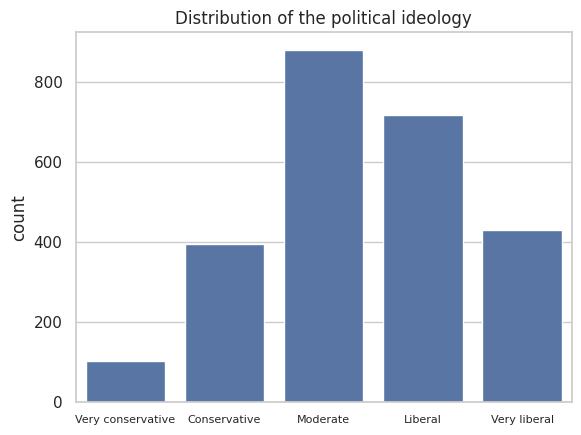

In [ ]:
# plot the distribution of y with
sns.set_theme(style="whitegrid")

sns.countplot(x=y)
plt.xticks(range(len(label_names)), label_names)
plt.xticks(rotation=0, fontsize=8)
plt.title("Distribution of the political ideology")
plt.savefig("y_dist")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=SEED)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=10)

In [ ]:
# baseline predictions
dt_clf.score(X_test, y_test)

0.4090909090909091

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, dt_clf.predict(X_test))
cm

array([[ 4,  5,  7,  1,  1],
       [16, 23, 26,  8,  3],
       [ 4, 23, 96, 42, 18],
       [ 2,  7, 38, 55, 35],
       [ 2,  3, 20, 38, 29]])

In [ ]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, dt_clf.predict(X_test), target_names=label_names))

                   precision    recall  f1-score   support

Very conservative       0.14      0.22      0.17        18
     Conservative       0.38      0.30      0.34        76
         Moderate       0.51      0.52      0.52       183
          Liberal       0.38      0.40      0.39       137
     Very liberal       0.34      0.32      0.33        92

         accuracy                           0.41       506
        macro avg       0.35      0.35      0.35       506
     weighted avg       0.41      0.41      0.41       506



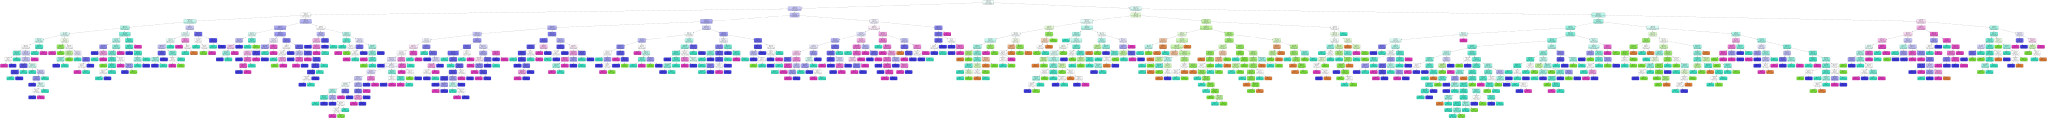

In [ ]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(dt_clf, out_file=None,
                                feature_names=X.columns,
                                class_names=df_cleaned['f_ideo'].astype(str),
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
# pruning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(1, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

rs = RandomizedSearchCV(dt_clf, param_dist, n_iter=100, cv=5, random_state=SEED)
rs.fit(X_train, y_train)

# best hyperparameters
rs.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 7}

In [ ]:
# use the best hyperparameters
best_dt = rs.best_estimator_
print(f"R^2: {best_dt.score(X_test, y_test)}\n")
print(classification_report(y_test, best_dt.predict(X_test), zero_division=0.0))

R^2: 0.541501976284585

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.53      0.53      0.53        76
           2       0.56      0.72      0.63       183
           3       0.52      0.49      0.50       137
           4       0.52      0.38      0.44        92

    accuracy                           0.54       506
   macro avg       0.43      0.42      0.42       506
weighted avg       0.52      0.54      0.52       506



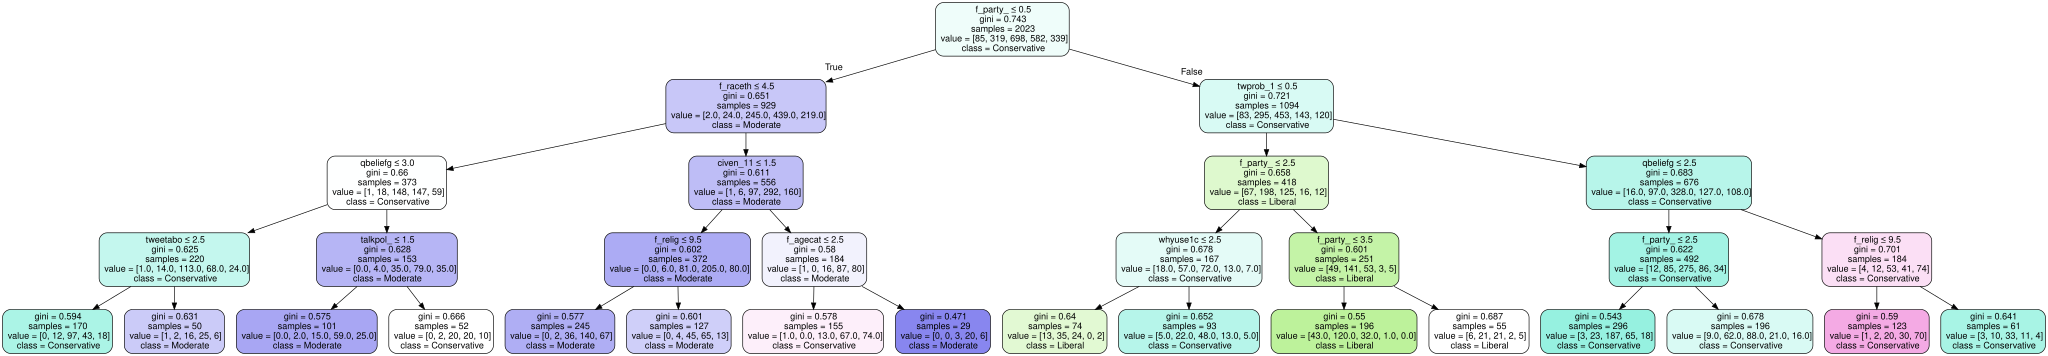

In [ ]:
dot_data = tree.export_graphviz(best_dt, out_file=None,
                                feature_names=X.columns,
                                class_names=df_cleaned['f_ideo'].astype(str),
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Decision Tree: One Hot and Ordinal Features

In [ ]:
X, y = one_hot_ordinal_dataset()
X_train, X_test, y_train, y_test = split_by_indices(X, y, train_indices, test_indices)

In [ ]:
# a baseline model
dt_clf = DecisionTreeClassifier(random_state=SEED)
dt_clf.fit(X_train, y_train)
dt_clf.score(X_test, y_test)

0.4189723320158103

In [ ]:
# hyperparameter tuning with randomizsed search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(1, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

rs = RandomizedSearchCV(dt_clf, param_dist, n_iter=100, cv=5, random_state=SEED)
rs.fit(X_train, y_train)

# best hyperparameters
rs.best_params_

{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1}

In [ ]:
# accuracy for the best model
rs.best_estimator_.score(X_test, y_test)

0.5237154150197628

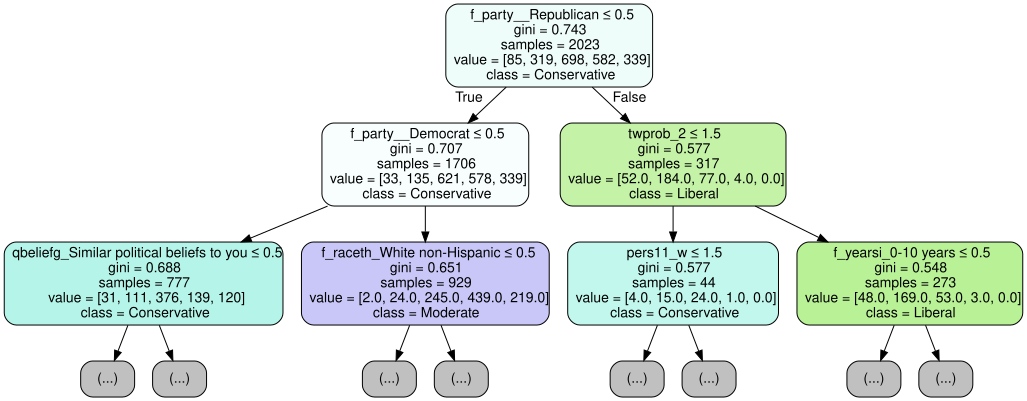

In [ ]:
# visualize the tree
dot_data = tree.export_graphviz(rs.best_estimator_, out_file=None,
                                feature_names=X.columns,
                                class_names=df_cleaned['f_ideo'].astype(str),
                                filled=True, rounded=True,
                                special_characters=True,
                                max_depth=2)
graph = graphviz.Source(dot_data)
graph

In [ ]:
# feature importance
importances = rs.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]
X.columns[indices][:15]

Index(['f_party__Republican', 'f_party__Democrat',
       'qbeliefg_Similar political beliefs to you',
       'f_raceth_White non-Hispanic', 'twprob_1', 'f_religc_Unaffiliated',
       'civen_11_Yes, I have done this in the past year', 'tweetabo',
       'consid_3', 'twprob_2',
       'covid_va_Yes, have received at least one dose of a vaccine',
       'twiden_1', 'f_educ_1', 'f_party__Something else',
       'civeng_6_Yes, I have done this in the past year'],
      dtype='object')

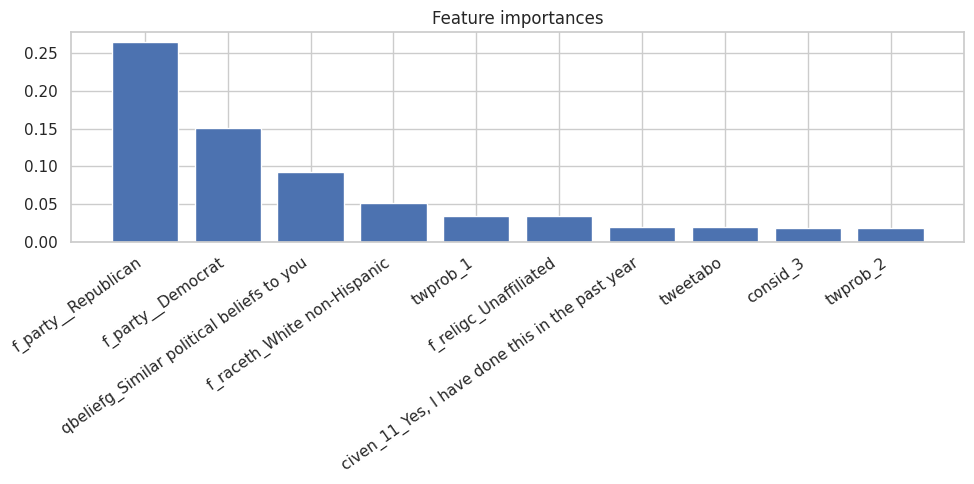

In [ ]:
# visualize the most important features
plt.figure(figsize=(10, 5))
plt.title("Feature importances")
plt.bar(range(10), importances[indices][:10])
plt.xticks(range(10), X.columns[indices][:10], rotation=35, ha='right')
plt.tight_layout()
plt.savefig("dt_feature_importance.png")
plt.show()

In [ ]:
# model evaluation
# confusion matrix
confusion_matrix(y_test, rs.best_estimator_.predict(X_test))

array([[  1,  10,   5,   1,   1],
       [  5,  41,  24,   5,   1],
       [  3,  21, 127,  27,   5],
       [  0,   2,  49,  68,  18],
       [  1,   2,  16,  45,  28]])

In [ ]:
# classification report
best_dt = rs.best_estimator_
print(label_names)
print(f"----")
print(f"accuracy: {best_dt.score(X_test, y_test)}\n")
print(classification_report(y_test, best_dt.predict(X_test), zero_division=0.0))

['Very conservative', 'Conservative', 'Moderate', 'Liberal', 'Very liberal']
----
accuracy: 0.5237154150197628

              precision    recall  f1-score   support

           0       0.10      0.06      0.07        18
           1       0.54      0.54      0.54        76
           2       0.57      0.69      0.63       183
           3       0.47      0.50      0.48       137
           4       0.53      0.30      0.39        92

    accuracy                           0.52       506
   macro avg       0.44      0.42      0.42       506
weighted avg       0.51      0.52      0.51       506



### Random Forest

In [ ]:
X, y = one_hot_ordinal_dataset()
X_train, X_test, y_train, y_test = split_by_indices(X, y, train_indices, test_indices)

In [ ]:
# a baseline RF model
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=SEED)
rf_clf.fit(X_train, y_train)
rf_clf.score(X_test, y_test)

0.5810276679841897

In [ ]:
# hyper-parameter tuning w/ randomized search
param_dist = {
    'n_estimators': randint(128, 2048),
    'max_depth': randint(1, 20),
    'min_samples_leaf': randint(1, 20),
    'criterion': ['gini', 'entropy']
}

rs = RandomizedSearchCV(rf_clf, param_dist, n_iter=8, cv=5, random_state=SEED, n_jobs=3)
rs.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=10),
                   n_iter=8, n_jobs=3,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a932e295a50>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a932e297ad0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a932e01c190>},
                   random_state=10)

In [ ]:
rs.best_params_

{'criterion': 'gini',
 'max_depth': 18,
 'min_samples_leaf': 14,
 'n_estimators': 1605}

In [ ]:
# the best model
rf_best_params = {
    'criterion': 'entropy',
    'max_depth': 12,
    'min_samples_leaf': 12,
    'n_estimators': 1274
}
best_rf = RandomForestClassifier(random_state=SEED, **rf_best_params)
best_rf.fit(X_train, y_train)
best_rf.score(X_test, y_test)

0.5948616600790514

In [ ]:
confusion_matrix(y_test, best_rf.predict(X_test))

array([[  0,  11,   6,   1,   0],
       [  0,  42,  33,   1,   0],
       [  0,   8, 149,  26,   0],
       [  0,   0,  41,  90,   6],
       [  0,   3,  14,  55,  20]])

In [ ]:
# classification report
print(label_names)
print(f"----")
print(f"R^2: {best_rf.score(X_test, y_test)}\n")
print(classification_report(y_test, best_rf.predict(X_test), zero_division=0.0))

['Very conservative', 'Conservative', 'Moderate', 'Liberal', 'Very liberal']
----
R^2: 0.5948616600790514

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.66      0.55      0.60        76
           2       0.61      0.81      0.70       183
           3       0.52      0.66      0.58       137
           4       0.77      0.22      0.34        92

    accuracy                           0.59       506
   macro avg       0.51      0.45      0.44       506
weighted avg       0.60      0.59      0.56       506



In [ ]:
# feature importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
X.columns[indices][:15]

Index(['f_party__Republican', 'f_party__Democrat', 'twprob_1', 'twprob_2',
       'f_attend', 'qbeliefg_Similar political beliefs to you',
       'f_religc_Unaffiliated', 'vaccnfdt', 'f_party__Independent', 'twiden_1',
       'f_religc_Protestant', 'f_relig_Protestant',
       'covid_va_Yes, have received at least one dose of a vaccine',
       'covid_va_No, have not received a vaccine',
       'civeng_1_No, I have not done this in the past year'],
      dtype='object')

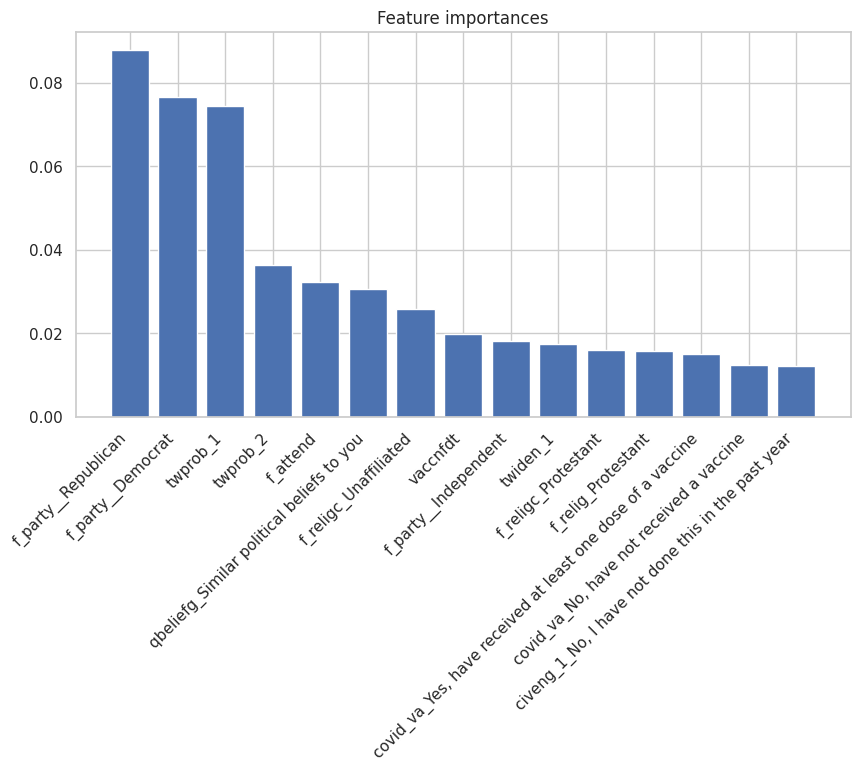

In [ ]:
# plot the feature importance
plt.figure(figsize=(10, 5))
plt.title("Feature importances")
plt.bar(range(15), importances[indices][:15])
plt.xticks(range(15), X.columns[indices][:15], rotation=45, ha='right')
plt.show()

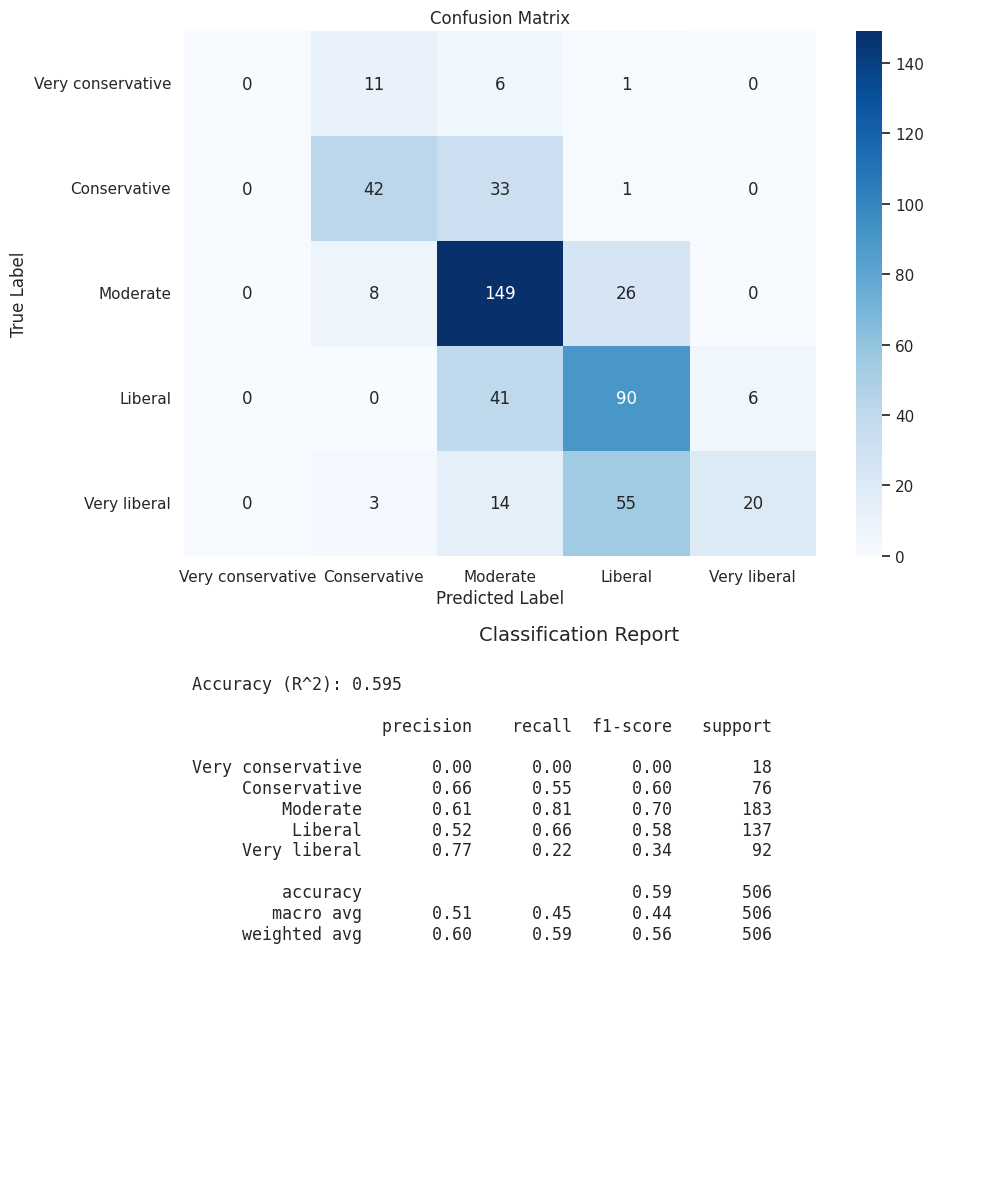

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
report_str = f"Accuracy (R^2): {best_rf.score(X_test, y_test):.3f}\n\n" + \
             classification_report(y_test, y_pred, target_names=label_names, zero_division=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=label_names, yticklabels=label_names)
ax1.set_title("Confusion Matrix")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")


ax2.axis('off')
ax2.text(0.01, 0.95, report_str, fontsize=12, fontfamily='monospace',
         verticalalignment='top')
ax2.set_title("Classification Report", fontsize=14)

plt.tight_layout()
plt.show()

### Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression

X, y = one_hot_ordinal_dataset()
X_train, X_test, y_train, y_test = split_by_indices(X, y, train_indices, test_indices)

# Initialize and train a Logistic Regression model
logreg = LogisticRegression(random_state=SEED, max_iter=10000)  # Increased max_iter for convergence
logreg.fit(X_train, y_train)

# Evaluate the model
print("Accuracy:", logreg.score(X_test, y_test))
print("Train_accuracy:", logreg.score(X_train, y_train))

Accuracy: 0.5098814229249012


In [ ]:
# Apply L1 and L2 regularization

# Initialize and train a Logistic Regression model with L1 regularization
l1_scores = []
best_score = 0
for i in range(1, 100):
    logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear',
                                   random_state=SEED, max_iter=10000, C=1/i) #C is inverse of regularization strength
    logreg_l1.fit(X_train, y_train)
    l1_scores.append(logreg_l1.score(X_test,y_test))
    if logreg_l1.score(X_test, y_test) > best_score:
        best_score = logreg_l1.score(X_test,y_test)
        best_C = 1/i
print(best_score)
print(best_C)

best_l1_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=SEED, max_iter=10000, C=best_C)
best_l1_model.fit(X_train, y_train)

# Initialize and train a Logistic Regression model with L2 regularization
l2_scores = []
best_score2 = 0
for i in range(1, 100):
    logreg_l2 = LogisticRegression(penalty='l2', solver='liblinear',
                                   random_state=SEED, max_iter=10000, C=1/i)
    logreg_l2.fit(X_train, y_train)
    l2_scores.append(logreg_l2.score(X_test,y_test))
    if logreg_l2.score(X_test, y_test) > best_score2:
        best_score2 = logreg_l2.score(X_test,y_test)
        best_C2 = 1/i

print(best_score2)
print(best_C2)

best_l2_model = LogisticRegression(penalty='l2', solver='liblinear', random_state=SEED, max_iter=10000, C=best_C2)
best_l2_model.fit(X_train, y_train)

train_acc_l1 = best_l1_model.score(X_train, y_train)
test_acc_l1 = best_l1_model.score(X_test, y_test)
train_acc_l2 = best_l2_model.score(X_train, y_train)
test_acc_l2 = best_l2_model.score(X_test, y_test)
print("Train Acc:", train_acc_l1, "Test Acc:", test_acc_l2)
print("Train Acc:", train_acc_l2, "Test Acc:", test_acc_l2)


0.5652173913043478
0.1111111111111111
0.5573122529644269
0.023255813953488372


LogisticRegression(C=0.023255813953488372, max_iter=10000, random_state=10,
                   solver='liblinear')

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, logreg.predict(X_test))

array([[  3,  10,   4,   0,   1],
       [  8,  37,  25,   4,   2],
       [  2,  21, 120,  30,  10],
       [  0,   2,  41,  66,  28],
       [  0,   5,  15,  40,  32]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get coefficients from models
l1_coefs = best_l1_model.coef_
l2_coefs = best_l2_model.coef_

num_classes = l1_coefs.shape[0]
num_features = l1_coefs.shape[1]

fig, axes = plt.subplots(num_classes, 2, figsize=(12, 4 * num_classes))

feature_names = X.columns

for i in range(num_classes):
    if num_classes == 1:
        ax1, ax2 = axes
    else:
        ax1, ax2 = axes[i]

    l1_values = l1_coefs[i]
    l2_values = l2_coefs[i]

    ax1.bar(range(num_features), l1_values)
    ax1.set_title(f"L1 Regularization - Class {i}")
    ax1.set_xlabel("Feature Index")
    ax1.set_ylabel("Coefficient Value")

    # Add labels to most important features (top 5 by absolute value)
    top_l1_indices = np.argsort(np.abs(l1_values))[-5:]
    for idx in top_l1_indices:
        ax1.text(idx, l1_values[idx], feature_names[idx], ha='center', va='bottom', fontsize=8)

    ax2.bar(range(num_features), l2_values)
    ax2.set_title(f"L2 Regularization - Class {i}")
    ax2.set_xlabel("Feature Index")
    ax2.set_ylabel("Coefficient Value")

    # Add labels to most important features (top 5 by absolute value)
    top_l2_indices = np.argsort(np.abs(l2_values))[-5:]
    for idx in top_l2_indices:
        ax2.text(idx, l2_values[idx], feature_names[idx], ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



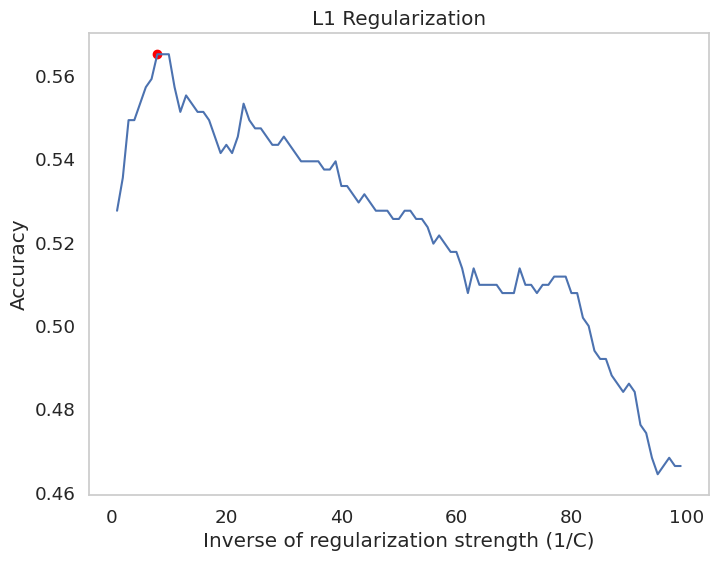

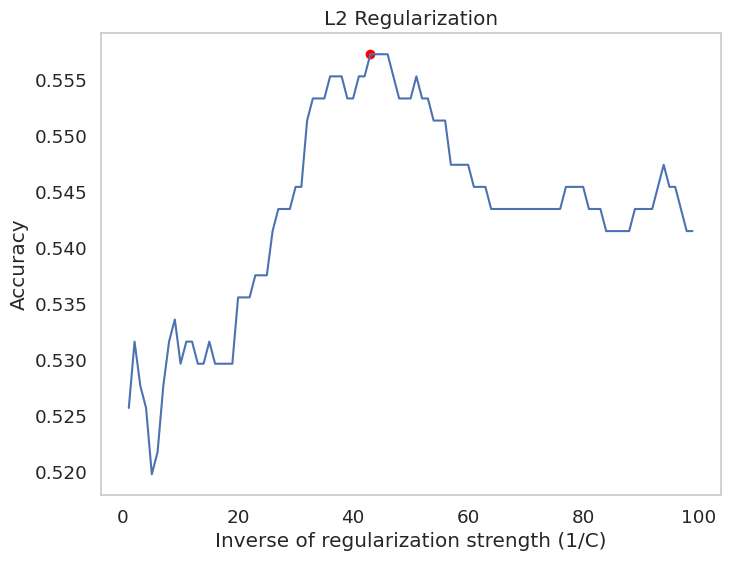

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# L1 Regularization Plot
logreg_l1_best = LogisticRegression(penalty='l1', solver='liblinear', random_state=SEED, max_iter=10000, C=best_C)
logreg_l1_best.fit(X_train, y_train)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 100), l1_scores)
plt.xlabel("Inverse of regularization strength (1/C)")
plt.ylabel("Accuracy")
plt.title("L1 Regularization")
plt.scatter(1/best_C, best_score, color='red')
plt.grid()
plt.show()


# L2 Regularization Plot

logreg_l2_best = LogisticRegression(penalty='l2', solver='liblinear', random_state=SEED, max_iter=10000, C=best_C2)
logreg_l2_best.fit(X_train, y_train)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 100), l2_scores)
plt.xlabel("Inverse of regularization strength (1/C)")
plt.ylabel("Accuracy")
plt.title("L2 Regularization")
plt.scatter(1/best_C2, best_score2, color='red')
plt.grid()
plt.show()

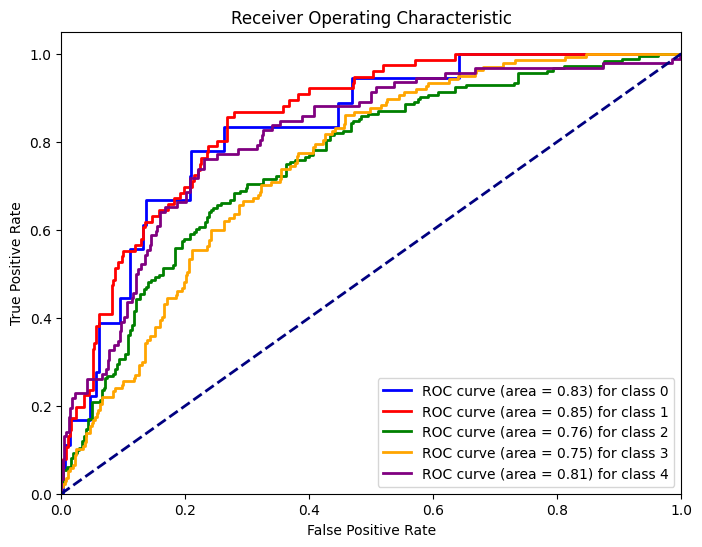

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the target variable
y_test_bin = label_binarize(y_test, classes=logreg.classes_)
n_classes = y_test_bin.shape[1]

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Predict probabilities for the current class
    y_score_class = logreg.predict_proba(X_test)[:, i]

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_class)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']  # Adjust colors as needed
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve (area = {roc_auc[i]:.2f}) for class {logreg.classes_[i]}')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Neural Network

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X, y = one_hot_ordinal_dataset()
X_train, X_test, y_train, y_test = split_by_indices(X, y, train_indices, test_indices)

X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float)
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
dataset_train = TensorDataset(X_train, y_train)
dataset_test = TensorDataset(X_test, y_test)

In [ ]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    """
    A simple feed-forward residual block with optional batch norm, dropout,
    and stochastic depth.
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        dropout=0.0,
        activation="relu",
        stochastic_depth_prob=0.0,
        use_batchnorm=True,
    ):
        super().__init__()
        self.stochastic_depth_prob = stochastic_depth_prob
        self.use_batchnorm = use_batchnorm
        self.activation_name = activation.lower()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.bn2 = nn.BatchNorm1d(input_dim) if use_batchnorm else nn.Identity()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, training=True):
        if training and torch.rand(1).item() < self.stochastic_depth_prob:
            return x  # Skip connection entirely

        residual = x  # Save for skip connection

        out = self.fc1(x)
        out = self.bn1(out)
        out = self.get_activation()(out)
        out = self.dropout(out)

        out = self.fc2(out)
        out = self.bn2(out)

        out += residual  # Residual connection
        return self.get_activation()(out)

    def get_activation(self):
        if self.activation_name == "relu":
            return nn.ReLU()
        elif self.activation_name == "gelu":
            return nn.GELU()
        else:
            raise ValueError(f"Unknown activation function: {self.activation_name}")

class AdvancedNN(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_dim=64,
        dropout=0.0,
        activation="relu",
        use_batchnorm=True,
        use_residual=True,
        stochastic_depth_prob=0.0,
    ):
        """
        An advanced MLP-style neural network with:
          - Configurable weight initialization
          - Optional batch normalization
          - Optional residual connections with stochastic depth
          - Dropout
        """
        super(AdvancedNN, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation_name = activation.lower()
        self.use_batchnorm = use_batchnorm
        self.use_residual = use_residual

        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.bn_input = nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()

        self.res_block1 = ResidualBlock(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            activation=self.activation_name,
            stochastic_depth_prob=stochastic_depth_prob,
            use_batchnorm=use_batchnorm,
        )

        self.res_block2 = ResidualBlock(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            activation=self.activation_name,
            stochastic_depth_prob=stochastic_depth_prob,
            use_batchnorm=use_batchnorm,
        )

        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.bn_input(x)
        x = self.get_activation()(x)
        x = self.dropout(x)

        x = self.res_block1(x, training=self.training)
        x = self.res_block2(x, training=self.training)

        x = self.output_layer(x)
        return x

    def get_activation(self):
        if self.activation_name == "relu":
            return nn.ReLU()
        elif self.activation_name == "gelu":
            return nn.GELU()
        else:
            raise ValueError(f"Unknown activation function: {self.activation_name}")

In [ ]:
from copy import deepcopy

def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_acc = 0.0
    best_f1 = 0.0
    best_model_state = None

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

        # Evaluate accuracy and F1-score
        model.eval()
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == batch_y).sum().item()
                total += batch_y.size(0)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        accuracy = correct / total
        f1 = f1_score(all_labels, all_preds, average='weighted')
        print(f"Test Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")

        if accuracy > best_acc:
            best_acc = accuracy
            best_model_state = deepcopy(model.state_dict())

        if f1 > best_f1:
            best_f1 = f1

    print(f"Best Test Accuracy: {best_acc:.4f}, Best F1 Score: {best_f1:.4f}")
    return best_model_state, best_acc

In [ ]:
# Hyperparameter search space
search_space = {
    "hidden_dim": [64, 128],
    "dropout": [0.0, 0.5, 0.6],
    "activation": ["relu", "gelu"],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "batch_size": [32, 64, 128],
    "use_batchnorm": [True, False],
    "use_residual": [True],
    "stochastic_depth_prob": [0.0, 0.1, 0.2],
    "weight_decay": [0.0, 5e-4, 1e-3],
}

num_trials = 16
best_hyperparams = None
best_val_acc = 0.0

for trial in range(num_trials):
    print(f"\nTrial {trial+1}/{num_trials}")

    params = {key: random.choice(values) for key, values in search_space.items()}

    # Create model
    model = AdvancedNN(
        input_dim=X.shape[1],
        output_dim=np.unique(y).shape[0],
        hidden_dim=params["hidden_dim"],
        dropout=params["dropout"],
        activation=params["activation"],
        use_batchnorm=params["use_batchnorm"],
        use_residual=params["use_residual"],
        stochastic_depth_prob=params["stochastic_depth_prob"]
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

    # Load data
    train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=params["batch_size"], shuffle=True)
    val_loader = torch.utils.data.DataLoader(dataset_test, batch_size=params["batch_size"], shuffle=False)

    # Train the model
    model_state, val_acc = train_model(model, criterion, optimizer, train_loader, val_loader, epochs=150)

    # best hyperparameters
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_hyperparams = params
        best_model_state = model_state

print("\nBest Hyperparameters Found:")
print(best_hyperparams)
print(f"Best Validation Accuracy: {best_val_acc}")

In [ ]:
import json

torch.save(best_model_state, "best_model.pth")
with open("model_config.json", "w") as f:
    json.dump(best_hyperparams, f)

In [ ]:
import json

best_model_state = torch.load("best_model.pth", weights_only=True)
with open("model_config.json", "r") as f:
    config = json.load(f)

mdl = AdvancedNN(input_dim=X.shape[1],
                   output_dim=np.unique(y).shape[0],
                   hidden_dim=config["hidden_dim"],
                   dropout=config["dropout"],
                   activation=config["activation"],
                   use_batchnorm=config["use_batchnorm"],
                   use_residual=config["use_residual"],
                   stochastic_depth_prob=config["stochastic_depth_prob"])

mdl.load_state_dict(best_model_state, strict=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mdl.to(device)
mdl.eval()

X_test = X_test.to(device)
with torch.no_grad():
    outputs = mdl(X_test)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu().numpy()
preds

array([3, 2, 1, 2, 3, 1, 1, 2, 2, 2, 1, 2, 2, 4, 4, 2, 3, 3, 4, 2, 3, 2,
       3, 2, 3, 2, 2, 4, 1, 2, 4, 2, 1, 3, 3, 2, 2, 3, 2, 1, 2, 2, 1, 3,
       2, 2, 2, 3, 1, 2, 2, 1, 2, 2, 2, 2, 3, 3, 2, 1, 3, 2, 3, 2, 1, 2,
       2, 2, 2, 3, 3, 2, 4, 2, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3, 2, 2, 2,
       3, 3, 4, 2, 2, 2, 3, 2, 4, 2, 2, 1, 3, 2, 2, 2, 2, 1, 3, 3, 3, 4,
       2, 2, 2, 2, 2, 2, 3, 2, 2, 4, 1, 4, 2, 4, 2, 2, 3, 3, 4, 2, 3, 2,
       2, 3, 1, 2, 2, 2, 1, 2, 2, 2, 1, 4, 2, 2, 1, 1, 3, 3, 3, 2, 2, 1,
       2, 2, 2, 1, 2, 2, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 1, 3, 2, 2, 2, 3,
       1, 3, 1, 2, 1, 2, 2, 1, 3, 2, 3, 4, 1, 1, 3, 3, 2, 2, 1, 2, 3, 3,
       4, 4, 3, 2, 2, 2, 4, 2, 2, 3, 3, 2, 2, 4, 2, 2, 3, 3, 2, 3, 3, 1,
       4, 2, 2, 2, 2, 1, 3, 3, 2, 3, 3, 3, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2,
       2, 2, 2, 2, 3, 2, 1, 4, 2, 3, 2, 3, 2, 2, 2, 2, 4, 2, 4, 3, 3, 2,
       2, 4, 2, 1, 3, 1, 3, 3, 1, 1, 2, 3, 3, 3, 1, 3, 2, 2, 2, 2, 1, 4,
       2, 4, 3, 2, 4, 2, 2, 2, 3, 3, 2, 1, 2, 2, 3,

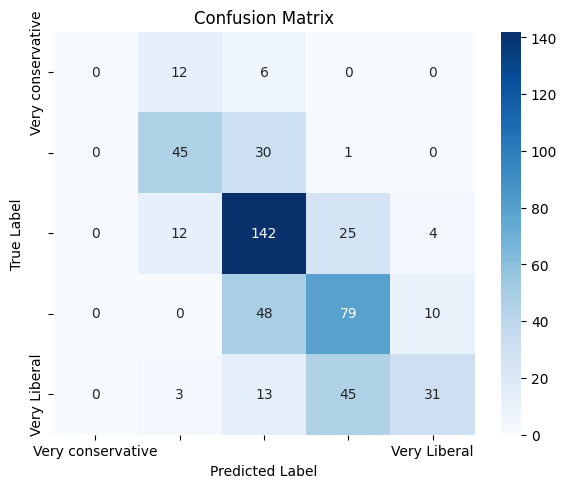

In [ ]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

fig = plt.figure(figsize=(6, 5))

ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Very conservative", "", "", "", "Very Liberal"], yticklabels=["Very conservative", "", "", "", "Very Liberal"])
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_test, preds)
print(f"Accuracy: {accuracy}")

f1 = f1_score(y_test, preds, average='weighted')
print(f"F1 Score: {f1}")

print(classification_report(y_test, preds, zero_division=0.0))

Accuracy: 0.5869565217391305
F1 Score: 0.5660657185855502
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.62      0.59      0.61        76
           2       0.59      0.78      0.67       183
           3       0.53      0.58      0.55       137
           4       0.69      0.34      0.45        92

    accuracy                           0.59       506
   macro avg       0.49      0.46      0.46       506
weighted avg       0.58      0.59      0.57       506



#### Shap

In [ ]:
%pip install shap

In [ ]:
import shap
import torch

best_model_state = torch.load("best_model.pth", weights_only=True)
with open("model_config.json", "r") as f:
    config = json.load(f)

mdl = AdvancedNN(input_dim=X.shape[1],
                   output_dim=np.unique(y).shape[0],
                   hidden_dim=config["hidden_dim"],
                   dropout=config["dropout"],
                   activation=config["activation"],
                   use_batchnorm=config["use_batchnorm"],
                   use_residual=config["use_residual"],
                   stochastic_depth_prob=config["stochastic_depth_prob"])

mdl.load_state_dict(best_model_state, strict=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mdl.to(device)
mdl.eval()

X, y = one_hot_ordinal_dataset()
X_test = X.iloc[test_indices]
y_test = y[test_indices]

# Convert PyTorch model to a SHAP-compatible function
def model_wrapper(x):
    mdl.to(device)
    with torch.no_grad():
        tensor_x = torch.tensor(x, dtype=torch.float32, device=device)  # Move input to GPU
        return mdl(tensor_x).detach().cpu().numpy()  # Move output back to CPU for SHAP

# Function to draw SHAP force plots for a subset of test samples
def draw_shap_force_plot(explainer, shap_values, X_subset, title="SHAP Force Plot"):
    """
    Draws a SHAP force plot for a given subset of test samples.

    Parameters:
        explainer: The SHAP explainer object.
        shap_values: Computed SHAP values for the subset.
        X_subset: The subset of test samples (Pandas DataFrame).
        title: The title of the plot.
    """
    shap.initjs()
    print(title)
    return shap.force_plot(
        explainer.expected_value[0],
        shap_values[..., 0],
        X_subset,
        feature_names=X_subset.columns
    )

# Get model predictions
with torch.no_grad():
    predictions = mdl(torch.tensor(X_test.values, dtype=torch.float32, device=device)).argmax(dim=1).cpu().numpy()

true_labels = y_test

# Identify correct and incorrect predictions
correct_indices = np.where(predictions == true_labels)[0]
incorrect_indices = np.where(predictions != true_labels)[0]

print(f"Total Correct Samples: {len(correct_indices)}, Incorrect Samples: {len(incorrect_indices)}")

num_samples = 20
correct_samples = np.random.choice(correct_indices, min(num_samples, len(correct_indices)), replace=False)
incorrect_samples = np.random.choice(incorrect_indices, min(num_samples, len(incorrect_indices)), replace=False)

# Apply SHAP KernelExplainer
explainer = shap.KernelExplainer(model_wrapper, X_test.iloc[:50], feature_names=X.columns)

Total Correct Samples: 297, Incorrect Samples: 209


In [ ]:
shap_values_20 = explainer.shap_values(X_test[:20])

  0%|          | 0/20 [00:00<?, ?it/s]

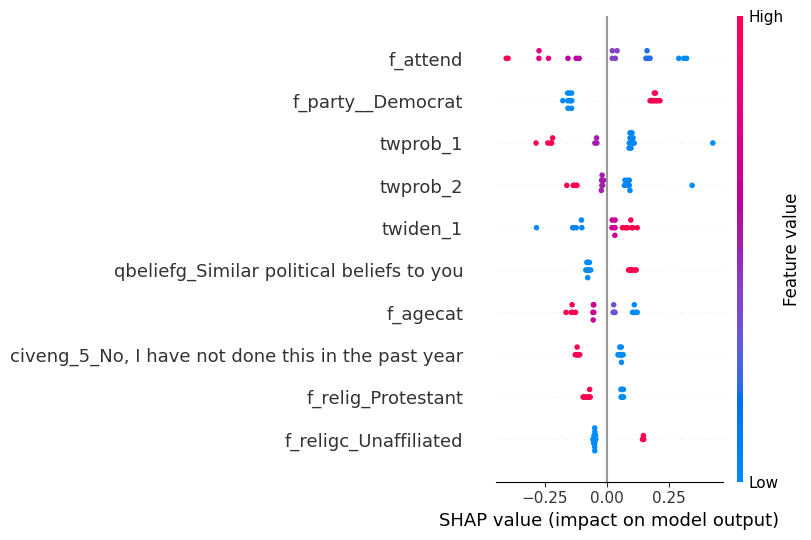

In [ ]:
plt = shap.summary_plot(shap_values_20[..., 4], X_test[:20], max_display=10)

In [ ]:
incorrect_0_indices = np.where(y_test == 0 & (predictions != y_test))[0]
shap_values_incorrect_0 = explainer.shap_values(X_test.iloc[incorrect_0_indices])

  0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
mdl(torch.tensor(X_test.loc[[2415]].values, dtype=torch.float32, device=device))

tensor([[-1.8088, -0.3013,  1.1878,  0.5487, -0.4246]],
       grad_fn=<AddmmBackward0>)

In [ ]:
X_test.iloc[[incorrect_0_indices[0]]]

,pers1_w9,pers11_w,selfmoni,talkpol_,concernt,concer_1,soceff1_,soceff_1,soceff_2,twdemocr,...,qbeliefg_A mix of political beliefs,qbeliefg_Different political beliefs from you,qbeliefg_Im not sure about their political beliefs,qbeliefg_Refused,qbeliefg_Similar political beliefs to you,f_religc_Catholic,f_religc_Other,f_religc_Protestant,f_religc_Refused,f_religc_Unaffiliated
2415,3,1,3,1,4,3,3,2,3,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values_incorrect_0[1, :, 1], X_test.iloc[[incorrect_0_indices[1]]], feature_names=X_test.columns)

In [ ]:
X_test.iloc[incorrect_0_indices][["f_party__Democrat", "f_attend"]]

,f_party__Democrat,f_attend
2415,0.0,3
1297,0.0,5
56,0.0,2
708,0.0,5
1599,0.0,6
174,0.0,5
1177,0.0,5
1274,0.0,3
96,0.0,4
1416,0.0,1


In [ ]:
# Compute SHAP values for selected correct samples
shap_values_correct = explainer.shap_values(X_test.iloc[correct_samples])

# Compute SHAP values for selected incorrect samples
shap_values_incorrect = explainer.shap_values(X_test.iloc[incorrect_samples])

In [ ]:
shap.summary_plot(shap_values_correct[..., 0], X_test.iloc[correct_samples], max_display=10)

In [ ]:
shap.summary_plot(shap_values_incorrect[..., 0], X_test.iloc[incorrect_samples], max_display=10)

### SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Split data into training and testing sets
X, y = one_hot_ordinal_dataset()
X_train, X_test, y_train, y_test = split_by_indices(X, y, train_indices, test_indices)

# Initialize and train an SVM model
svm_model = SVC(probability=True, random_state=SEED)
svm_model.fit(X_train, y_train)

# Evaluate the model
accuracy = svm_model.score(X_test, y_test)
print(f"Accuracy of SVM: {accuracy}")

# Further evaluation metrics as needed (e.g., classification report)
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0.0))

Accuracy of SVM: 0.5770750988142292


NameError: name 'classification_report' is not defined

In [ ]:
# Wrapping the PyTorch model into a scikit-learn-style classifier (AdvancedNN)

from sklearn.base import BaseEstimator, ClassifierMixin
import torch

class NeuralNetworkClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X, y):
        self.model.to(self.device)
        self.model.eval()
        return self

    def predict(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
        return probabilities.cpu().numpy()

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "best_model.pth"
model_config_path = "model_config.json"
with open(model_config_path, "r") as f:
    config = json.load(f)

best_model_state = torch.load(model_path, weights_only=True)

model = AdvancedNN(input_dim=X.shape[1],
                   output_dim=np.unique(y).shape[0],
                   hidden_dim=config["hidden_dim"],
                   dropout=config["dropout"],
                   activation=config["activation"],
                   use_batchnorm=config["use_batchnorm"],
                   use_residual=config["use_residual"],
                   stochastic_depth_prob=config["stochastic_depth_prob"])

model.load_state_dict(best_model_state, strict=False)
nn_clf = NeuralNetworkClassifier(model=model, device=device)

## Performance Evaluation

In [ ]:
# !pip install wandb

In [ ]:
# calculate the evaluation metrics for all models

models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Logistic Regression": logreg,
    "Logistic Regression L1": best_l1_model,
    "Logistic Regression L2": best_l2_model,
    "Neural Network": nn_clf
}

results = []
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)  # for AUC-ROC

    results.append({
    "Model": model_name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0), # if no positive result, return 0
    "Precision (Weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall (Macro)": recall_score(y_test, y_pred, average="macro"),
    "Recall (Weighted)": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score (Macro)": f1_score(y_test, y_pred, average="macro"),
    "F1-Score (Weighted)": f1_score(y_test, y_pred, average="weighted"),
    "AUC-ROC (Macro)": roc_auc_score(y_test, y_prob, average="macro", multi_class="ovr")
})

df_results = pd.DataFrame(results)
df_results

In [ ]:
# Visualize the model performance comparison

import matplotlib.pyplot as plt
import seaborn as sns

df_results_sorted = df_results.sort_values(by='Accuracy', ascending=False)

df_filtered = df_results_sorted[["Model", "Accuracy", "Precision (Weighted)", "Recall (Weighted)", "F1-Score (Weighted)"]]

# long dataframe
df_long = df_filtered.melt(id_vars="Model", var_name="Metric", value_name="Score")

color_mapping = {
    "Decision Tree": "#2ca02c", "Random Forest": "#98df8a",
    "Logistic Regression": "#1f77b4", "Logistic Regression L1": "#6baed6", "Logistic Regression L2": "#aec7e8",  # Blue shades for logistic models
    "Neural Network": "#7f7f7f"
}

custom_palette = [color_mapping[model] for model in df_results_sorted["Model"]]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Metric", y="Score", hue="Model", data=df_long, palette=custom_palette)

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title("Model Performance Comparison", fontsize=14)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0.4, 0.65) # scale
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [ ]:
# Plot ROC Curve for each model

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class classification (One-vs-Rest)
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

colors = ['blue', 'red', 'green', 'orange', 'purple', 'black']

plt.figure(figsize=(8, 6))

for (model_name, model), color in zip(models.items(), colors):
    y_score = model.predict_proba(X_test)

    # macro-average ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC curve (area = {roc_auc:.2f}) for {model_name}')

# baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison: ROC Curves (AUC-Macro)")
plt.legend(loc="lower right")
plt.grid()

plt.show()

In [ ]:
# Per-class performance

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_class_performance = pd.DataFrame({
    "Class": ["Very Liberal", "Liberal", "Moderate", "Conservative", "Very Conservative"],
    "Decision Tree": [0.39, 0.48, 0.63, 0.53, 0.07],
    "Random Forest": [0.34, 0.58, 0.70, 0.60, 0.00],
    "Logistic Regression": [0.44, 0.54, 0.67, 0.53, 0.00],
    "Logistic Regression L1": [0.42, 0.54, 0.65, 0.54, 0.09],
    "Logistic Regression L2": [0.39, 0.56, 0.67, 0.57, 0.00],
    "Neural Network": [0.39, 0.56, 0.67, 0.60, 0.00]
})

df_long_class = df_class_performance.melt(id_vars="Class", var_name="Model", value_name="F1-Score")

color_palette = {
    "Decision Tree": "#2ca02c", "Random Forest": "#98df8a",
    "Logistic Regression": "#1f77b4", "Logistic Regression L1": "#6baed6", "Logistic Regression L2": "#aec7e8",  # Blue shades for logistic models
    "Neural Network": "#7f7f7f"
}

sns.set_theme(style="whitegrid")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# background color
ax.set_facecolor("white")
plt.axvspan(-0.5, 1.5, color='#dbe9f6', alpha=0.3)
plt.axvspan(2.5, 4.5, color='#f6dbdb', alpha=0.3)

bars = sns.barplot(x="Class", y="F1-Score", hue="Model", data=df_long_class, palette=color_palette, ax=ax)

# Add labels on bars
for p in bars.patches:
    if isinstance(p, plt.Rectangle) and p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')

# Formatting
plt.title("Per-Class Prediction Performance (F1-Score)", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 0.8)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Ensemble Methods

In [ ]:
from sklearn.ensemble import VotingClassifier

# Ensemble use voting

# Hard Voting
voting_clf_hard = VotingClassifier(
    estimators=[
        ('decision_tree', best_dt),
        ('random_forest', best_rf),
        ('logreg_l1', best_l1_model),
        ('logreg_l2', best_l2_model),
        ('svm', svm_model),
        ('neural_network', nn_clf)
    ],
    voting='hard'
)

voting_clf_hard.fit(X_train, y_train)

# Predict and evaluate
y_pred_hard = voting_clf_hard.predict(X_test)
accuracy_hard = accuracy_score(y_test, y_pred_hard)
print(f"Hard Voting Accuracy: {accuracy_hard * 100:.2f}%")


Hard Voting Accuracy: 59.49%
Soft Voting Accuracy: 57.51%
Weighted Soft Voting Accuracy: 57.51%


In [ ]:

# Soft Voting

voting_clf_soft = VotingClassifier(
    estimators=[
        ('decision_tree', best_dt),
        ('random_forest', best_rf),
        ('logreg_l1', best_l1_model),
        ('logreg_l2', best_l2_model),
        ('svm', svm_model),
        ('neural_network', nn_clf)
    ],
    voting='soft'
)

voting_clf_soft.fit(X_train, y_train)

y_pred_soft = voting_clf_soft.predict(X_test)
accuracy_soft = accuracy_score(y_test, y_pred_soft)
print(f"Soft Voting Accuracy: {accuracy_soft * 100:.2f}%")


In [ ]:

# Weighted Soft Voting

voting_clf_weighted = VotingClassifier(
    estimators=[
        ('decision_tree', best_dt),
        ('random_forest', best_rf),
        ('logreg_l1', best_l1_model),
        ('logreg_l2', best_l2_model),
        ('svm', svm_model),
        ('neural_network', nn_clf)
    ],
    voting='soft',
    weights=[2, 3, 1, 2, 1, 1]  # weight
)

voting_clf_weighted.fit(X_train, y_train)
y_pred_weighted = voting_clf_weighted.predict(X_test)
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
print(f"Weighted Soft Voting Accuracy: {accuracy_weighted * 100:.2f}%")

In [ ]:
# the report of the ensemble models

from sklearn.metrics import classification_report

ensemble_reports = {
    "Voting Classifier (Hard)": classification_report(y_test, voting_clf_hard.predict(X_test), zero_division=0.0),
    "Voting Classifier (Soft)": classification_report(y_test, voting_clf_soft.predict(X_test), zero_division=0.0),
    "Voting Classifier (Weighted Soft)": classification_report(y_test, voting_clf_weighted.predict(X_test), zero_division=0.0)
}

for model, report in ensemble_reports.items():
    print(f"Classification Report for {model}:")
    print(report)
    print("="*100)


In [ ]:
# final comparison report

import ace_tools as tools

data = {
    "Model": [
        "Decision Tree", "Random Forest", "Logistic Regression",
        "Logistic Regression L1", "Logistic Regression L2", "Neural Network",
        "Voting Classifier (Hard)", "Voting Classifier (Soft)", "Voting Classifier (Weighted Soft)"
    ],
    "Accuracy": [0.52, 0.59, 0.51, 0.57, 0.56, 0.58, 0.58, 0.58, 0.57],
    "Precision (Macro)": [0.44, 0.51, 0.44, 0.46, 0.50, 0.52, 0.47, 0.47, 0.46],
    "Precision (Weighted)": [0.51, 0.60, 0.50, 0.55, 0.55, 0.62, 0.57, 0.57, 0.56],
    "Recall (Macro)": [0.42, 0.44, 0.43, 0.43, 0.44, 0.47, 0.44, 0.45, 0.45],
    "Recall (Weighted)": [0.52, 0.59, 0.51, 0.57, 0.56, 0.58, 0.58, 0.58, 0.57],
    "F1-Score (Macro)": [0.42, 0.44, 0.43, 0.44, 0.45, 0.45, 0.44, 0.45, 0.44],
    "F1-Score (Weighted)": [0.51, 0.56, 0.50, 0.55, 0.54, 0.56, 0.55, 0.56, 0.55],
    "AUC-ROC (Macro)": [0.76, 0.84, 0.80, 0.83, 0.82, 0.84, None, None, None]
}

df = pd.DataFrame(data)

tools.display_dataframe_to_user(name="Final Model Performance Table", dataframe=df)

## Results Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def visualize_tsne(model, X_train, X_test, y_train, y_test, perplexity=10, seed=42):
    """
    Visualize t-SNE of the dataset, with correct predictions as circles and incorrect as 'x'.

    Parameters:
        model: Trained model with a .predict() method.
        X_train: Training feature set.
        X_test: Test feature set.
        y_train: Training labels.
        y_test: True labels for test set.
        perplexity: Perplexity parameter for t-SNE.
        seed: Random seed for reproducibility.
    """

    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(np.vstack((X_train, X_test)))
    X_train_scaled = X_scaled[:len(X_train)]
    X_test_scaled = X_scaled[len(X_train):]

    # Fit t-SNE
    tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity)
    X_embedded = tsne.fit_transform(X_scaled)
    X_train_embedded, X_test_embedded = X_embedded[:len(X_train)], X_embedded[len(X_train):]

    y_pred = model.predict(X_test)

    label_var = {
        "f_ideo": {"Very conservative": 0, "Conservative": 1, "Moderate": 2, "Liberal": 3, "Very liberal": 4},
    }

    label_mapping = {v: k for k, v in label_var["f_ideo"].items()}

    ideology_palette = {
        "Very conservative": "#b01c1e",
        "Conservative": "#c65756",
        "Moderate": "#dbdbdb",
        "Liberal": "#5376ae",
        "Very liberal": "#1b438f"}

    plt.figure(figsize=(10, 10))

    # traing data
    sns.scatterplot(x=X_train_embedded[:, 0], y=X_train_embedded[:, 1],
                    hue=[label_mapping[label] for label in y_train],
                    palette=ideology_palette, marker="o", edgecolor=None, alpha=.3)

    # test data
    for i in range(len(X_test)):
        marker = 'o' if y_pred[i] == y_test[i] else 'X'
        plt.scatter(X_test_embedded[i, 0], X_test_embedded[i, 1],
                    c=[ideology_palette[label_mapping[y_test[i]]]], marker=marker,
                    edgecolors='black', linewidth=1.2, s=100)

    plt.title('t-SNE Visualization of Model Predictions')
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend(title="Ideology")
    plt.show()


In [ ]:
# Decision Tree

visualize_tsne(best_dt, X_train, X_test, y_train, y_test)


In [ ]:
# Logistic Regression L2

visualize_tsne(best_l2_model, X_train, X_test, y_train, y_test)

In [ ]:
# neural network model

visualize_tsne(nn_clf, X_train, X_test, y_train, y_test)